
# Netflix Data Analysis

## Notebook 1: Data Understanding

**Author:** Arpita Nair

### Objective

The objective of this notebook is to understand the Netflix dataset before performing any data cleaning or analysis.

This notebook will:

- Import required libraries
- Load the dataset
- Explore its structure
- Understand each column
- Identify data quality issues

In [2]:
import pandas as pd

## Step 1: Import Required Libraries

In this section, we import the Python libraries needed for data analysis.

In [3]:

import pandas as pd
import numpy as np

## Step 2: Load the Dataset

In this step, we load the original Netflix dataset into a pandas DataFrame for analysis.

In [4]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 3: Check Dataset Shape

Let's find out how many rows and columns are present in the dataset.

In [6]:
df.shape

(8807, 12)

## Step 4: View Column Names

Let's inspect all the column names available in the Netflix dataset.

In [7]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

## Step 5: Inspect Data Types

Let's inspect the data types of each column to understand how the dataset is stored.


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Step 6: Check Missing Values

Let's identify the number of missing values in each column.



In [9]:
df.isnull().sum()




show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Step 7: Check Duplicate Records

Let's identify duplicate rows before cleaning the dataset.









In [10]:
df.duplicated().sum()

np.int64(0)

# Step 8: Summary Statistics

Let's examine the statistical summary of the dataset.|



In [11]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Step 9: Explore Categorical Columns

Let's summarize the categorical columns in the dataset.

In [12]:
df.describe(include="object")

C:\Users\naira\AppData\Local\Temp\ipykernel_29368\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


# Data Profiling Summary

## Dataset Overview
- Total Rows: 8,807
- Total Columns: 12
- Duplicate Rows: 0

## Missing Values
- Director: 2,634
- Cast: 825
- Country: 831
- Date Added: 10
- Rating: 4
- Duration: 3

## Initial Observations
- The dataset contains Movies and TV Shows.
- Movies are more common than TV Shows.
- The United States is the most frequent country entry.
- TV-MA is the most common content rating.
- The `listed_in` column contains multiple genres.
- The `country` column contains multiple countries in some rows.
- The `duration` column mixes movie durations and TV show seasons.

## Data Cleaning Required
- Handle missing values.
- Convert `date_added` to datetime.
- Split multiple countries.
- Split multiple genres.
- Separate movie durations from TV show seasons.

# Milestone 6: Data Cleaning

Before cleaning the dataset, we'll create a working copy to preserve the original data.

In [13]:
df_clean = df.copy()

In [14]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [16]:
len(df_clean)

8807

In [17]:
missing_percentage.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

## Cleaning Director Column

In [18]:
df_clean["director"].isnull().sum()

np.int64(2634)

In [19]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

In [20]:
df_clean["director"].isnull().sum()

np.int64(0)

## Investigating Missing Country Values



In [21]:
df_clean[df_clean["country"].isnull()].head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,Unknown,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,"September 22, 2021",2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...


## Checking Duplicate Records

In [22]:
df_clean.duplicated().sum()


np.int64(0)

In [23]:
df_clean["date_added"].dtype

<StringDtype(storage='python', na_value=nan)>

## Converting Date Column

In [24]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [25]:
df_clean["date_added"].isnull().sum()

np.int64(98)

In [26]:
df_clean["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [27]:
df_clean["date_added"].dtype



dtype('<M8[us]')

In [28]:
df_clean["date_added"].isnull().sum()

np.int64(98)

In [29]:
df_clean[df_clean["date_added"].isna()][["title", "date_added"]].head(20)

,title,date_added
6066,A Young Doctor's Notebook and Other Stories,NaT
6079,Abnormal Summit,NaT
6174,Anthony Bourdain: Parts Unknown,NaT
6177,忍者ハットリくん,NaT
6213,Bad Education,NaT
6279,Being Mary Jane: The Series,NaT
6304,"Big Dreams, Small Spaces",NaT
6318,Bitten,NaT
6357,Bondi Rescue,NaT
6361,Borderline,NaT


In [30]:
df.loc[df_clean["date_added"].isna(), ["title", "date_added"]].head(20)

,title,date_added
6066,A Young Doctor's Notebook and Other Stories,NaN
6079,Abnormal Summit,"August 4, 2017"
6174,Anthony Bourdain: Parts Unknown,NaN
6177,忍者ハットリくん,"December 23, 2018"
6213,Bad Education,"December 15, 2018"
6279,Being Mary Jane: The Series,"July 1, 2017"
6304,"Big Dreams, Small Spaces","July 26, 2019"
6318,Bitten,"May 26, 2016"
6357,Bondi Rescue,"November 1, 2019"
6361,Borderline,"December 2, 2017"


In [31]:
df.loc[6079, "date_added"]






' August 4, 2017'

In [32]:
df_clean.loc[6079, "date_added"]

NaT

In [33]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")

In [34]:
df.loc[6079, "date_added"]


' August 4, 2017'

In [35]:
df_clean = df.copy()


In [36]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [37]:
df_clean["date_added"].isnull().sum()


np.int64(98)

In [38]:
test_df = pd.read_csv("../data/raw/netflix_titles.csv")

print(test_df.shape)
print(test_df["date_added"].isnull().sum())

(8807, 12)
10


In [39]:

df_clean = test_df.copy()


In [40]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [41]:
print(df_clean["date_added"].dtype)
print(df_clean["date_added"].isnull().sum())

datetime64[us]
98


In [42]:
test_df.loc[[6079, 6177, 6304], "date_added"]

6079        August 4, 2017
6177     December 23, 2018
6304         July 26, 2019
Name: date_added, dtype: str

In [43]:
pd.to_datetime(
    test_df["date_added"],
    format="mixed",
    errors="coerce"
).isnull().sum()

np.int64(10)

In [44]:
format="mixed"

In [45]:
pd.to_datetime(
    test_df["date_added"],
    format="mixed",
    errors="coerce"
).isnull().sum()

np.int64(10)

## Feature Engineering: Extract Date Components

In [46]:
df_clean["year_added"] = df_clean["date_added"].dt.year

In [47]:
df_clean["month_added"] = df_clean["date_added"].dt.month_name()


In [48]:
df_clean["day_added"] = df_clean["date_added"].dt.day

In [49]:
df_clean[
    ["date_added", "year_added", "month_added", "day_added"]
].head(10)

,date_added,year_added,month_added,day_added
0,2021-09-25,2021.0,September,25.0
1,2021-09-24,2021.0,September,24.0
2,2021-09-24,2021.0,September,24.0
3,2021-09-24,2021.0,September,24.0
4,2021-09-24,2021.0,September,24.0
5,2021-09-24,2021.0,September,24.0
6,2021-09-24,2021.0,September,24.0
7,2021-09-24,2021.0,September,24.0
8,2021-09-24,2021.0,September,24.0
9,2021-09-24,2021.0,September,24.0


In [50]:
print(df.shape)
print(df["date_added"].isnull().sum())

(8807, 12)
10


### Cleaning Step: Handling Missing `date_added`

- The `date_added` column contained 10 missing values (0.11% of the dataset).
- Since this column is essential for time-based analysis, missing dates could not be reliably imputed.
- Only rows with missing `date_added` values were removed.
- This ensured accurate trend analysis while preserving 99.89% of the dataset.

In [51]:
test_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [52]:
df["rating"].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Name: rating, Length: 8807, dtype: bool

In [53]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [54]:
df_clean[df_clean["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,2017-01-26,2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...,2017.0,January,26.0
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,2016-12-01,2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel...",2016.0,December,1.0
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,2018-02-01,2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take...",2018.0,February,1.0
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,2017-03-01,2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c...",2017.0,March,1.0


## Handling Missing Values in the Rating Column

In [55]:
df_clean["rating"] = df_clean["rating"].fillna("Unknown")

In [56]:
df_clean["rating"].isnull().sum()


np.int64(0)

In [57]:
df_clean["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [58]:
df_clean[df_clean["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017.0,April,4.0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016.0,September,16.0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016.0,August,15.0


## Fixing Misplaced Duration Values

In [59]:
mask = df_clean["rating"].isin(["74 min", "84 min", "66 min"])

mask.sum()

np.int64(3)

In [60]:
df_clean.loc[mask, "duration"] = df_clean.loc[mask, "rating"]

In [61]:
df_clean.loc[mask, "rating"] = "Unknown"

In [62]:
df_clean.loc[mask]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,Unknown,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017.0,April,4.0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,Unknown,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016.0,September,16.0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,Unknown,66 min,Movies,The comic puts his trademark hilarious/thought...,2016.0,August,15.0


In [63]:
df_clean["country"].isnull().sum()

np.int64(831)

In [64]:
df_clean[df_clean["country"].isnull()].head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,24.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,24.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0,September,24.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,September,24.0
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B...",2021.0,September,24.0
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,2021-09-23,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ...",2021.0,September,23.0
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...,2021.0,September,22.0
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...,2021.0,September,22.0
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,2021-09-22,2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...,2021.0,September,22.0
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,2021-09-22,2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...,2021.0,September,22.0


In [65]:
df_clean[df_clean["country"].isnull()][["title","director","cast","listed_in"]].head(10)

,title,director,cast,listed_in
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...","Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,NaN,NaN,"Docuseries, Reality TV"
5,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...","TV Dramas, TV Horror, TV Mysteries"
6,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Children & Family Movies
10,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,"Crime TV Shows, Docuseries, International TV S..."
11,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...","Crime TV Shows, International TV Shows, TV Act..."
13,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...","Children & Family Movies, Comedies"
14,Crime Stories: India Detectives,NaN,NaN,"British TV Shows, Crime TV Shows, Docuseries"
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,"Documentaries, International Movies"
18,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",Thrillers


In [66]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [67]:
df_clean["country"].isnull().sum()

np.int64(0)

In [68]:
df_clean["country"].value_counts().head(15)


country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Turkey             105
Nigeria             95
Australia           87
Taiwan              81
Name: count, dtype: int64

## Cleaning Log: Country Column

**Problem**
- The `country` column contained 831 missing values.

**Investigation**
- The missing records were inspected using the title, director, cast, and genre columns.
- No reliable rule existed to infer the missing countries.

**Decision**
- Missing values were replaced with `"Unknown"`.

**Reason**
- Preserved all records.
- Avoided introducing incorrect assumptions.
- Maintained transparency in the dataset.

In [69]:
df_clean[df_clean["cast"].isnull()][
    ["title", "director", "country", "listed_in"]
].head(10)

,title,director,country,listed_in
0,Dick Johnson Is Dead,Kirsten Johnson,United States,Documentaries
3,Jailbirds New Orleans,NaN,Unknown,"Docuseries, Reality TV"
10,"Vendetta: Truth, Lies and The Mafia",NaN,Unknown,"Crime TV Shows, Docuseries, International TV S..."
14,Crime Stories: India Detectives,NaN,Unknown,"British TV Shows, Crime TV Shows, Docuseries"
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",Unknown,"Documentaries, International Movies"
20,Monsters Inside: The 24 Faces of Billy Milligan,Olivier Megaton,Unknown,"Crime TV Shows, Docuseries, International TV S..."
45,My Heroes Were Cowboys,Tyler Greco,Unknown,Documentaries
66,Raja Rasoi Aur Anya Kahaniyan,NaN,India,"Docuseries, International TV Shows"
69,Stories by Rabindranath Tagore,NaN,India,"International TV Shows, TV Dramas"
74,The World's Most Amazing Vacation Rentals,NaN,Unknown,Reality TV


## Handling Missing Cast Values

### Investigation

The `cast` column contains 825 missing values.

### Decision

The missing values are **left unchanged**.

### Reason

- The current project does not include actor-based analysis.
- Missing cast values do not affect the planned dashboard.
- Filling them with `"Unknown"` would introduce an artificial actor category.
- Preserving the original missing values maintains the integrity of the dataset.

# Exploratory Data Analysis (EDA)

## Business Question 1

### Does Netflix have more Movies or TV Shows?

In [70]:
df_clean["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [71]:
(df_clean["type"].value_counts(normalize=True) * 100).round(2)


type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

In [72]:
import matplotlib.pyplot as plt

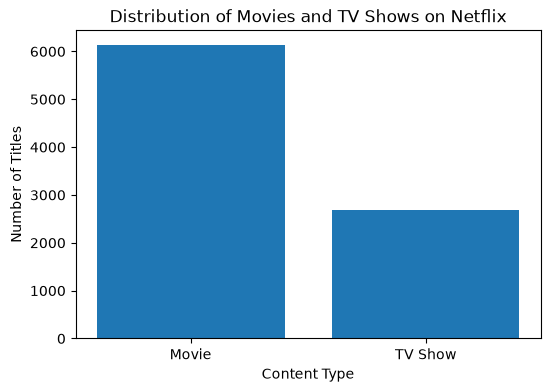

In [73]:
type_counts = df_clean["type"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(type_counts.index, type_counts.values)

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

## Business Question 1: Does Netflix have more Movies or TV Shows?

### Objective
Determine the distribution of content types available on Netflix.

### Why It Matters
Understanding the balance between movies and TV shows helps evaluate Netflix's content strategy and investment priorities.

### Observation
- Movies: 6,131
- TV Shows: 2,676
- Movies account for approximately 70% of the dataset.

### Business Insight
Netflix's library is heavily dominated by movies, indicating a stronger investment in movie content compared to TV shows.

### Recommendation
If user engagement data also shows high movie consumption, Netflix should continue investing in movies. However, if TV shows generate higher retention despite fewer titles, increasing investment in original TV series could be beneficial.

In [74]:
df_clean["listed_in"].head()




0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str

In [75]:
genres = df_clean["listed_in"].str.split(", ")

genres.head()

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in, dtype: object

In [76]:
genres = df_clean["listed_in"].str.split(", ")

In [77]:
genres_exploded = genres.explode()

In [78]:
genres_exploded.head(15)




0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
2    International TV Shows
2     TV Action & Adventure
3                Docuseries
3                Reality TV
4    International TV Shows
4         Romantic TV Shows
4               TV Comedies
5                 TV Dramas
5                 TV Horror
5              TV Mysteries
Name: listed_in, dtype: str

In [79]:
genre_counts = genres_exploded.value_counts()

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [80]:
genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

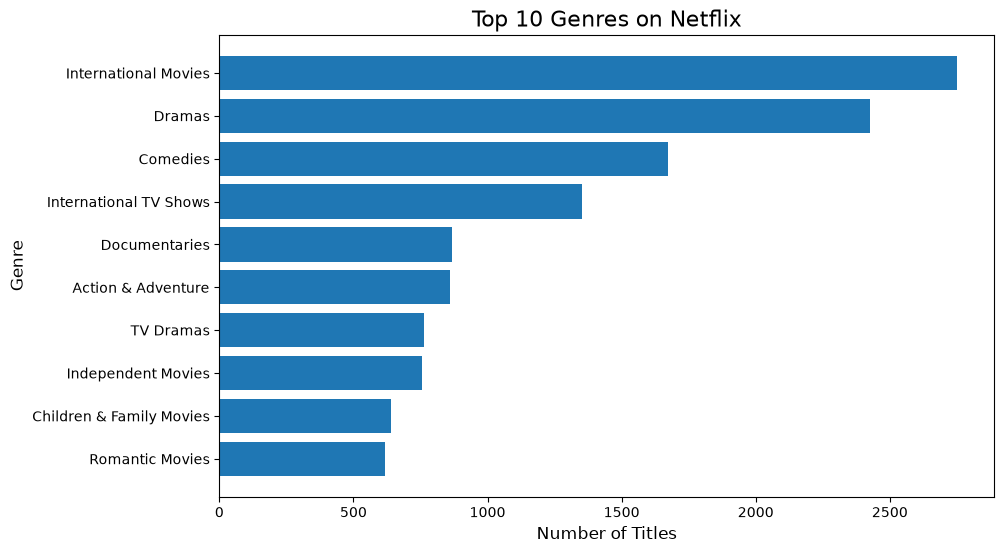

In [81]:
import matplotlib.pyplot as plt

top_genres = genre_counts.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_genres.index, top_genres.values)

plt.title("Top 10 Genres on Netflix", fontsize=16)

plt.xlabel("Number of Titles", fontsize=12)

plt.ylabel("Genre", fontsize=12)

plt.gca().invert_yaxis()

plt.show()

## Business Question 2: Which Genres Dominate Netflix?

### Objective
Identify the most common genres available on Netflix.

### Why It Matters
Understanding genre popularity helps Netflix decide where to invest in future content and identify audience preferences.

### Observation
- (Write the top 3 genres from your output.)
- Compare their counts.
- Mention whether Movies or TV Shows seem to dominate these genres.

### Business Insight
The Netflix catalog is heavily concentrated in these genres, indicating higher investment and likely stronger audience demand.

### Recommendation
Netflix should continue strengthening high-performing genres while also investing in emerging or underrepresented genres to diversify the catalog.

In [82]:
top_countries = df_clean["country"].value_counts().head(10)

top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [83]:
country_counts = df_clean[df_clean["country"] != "Unknown"]["country"].value_counts().head(10)

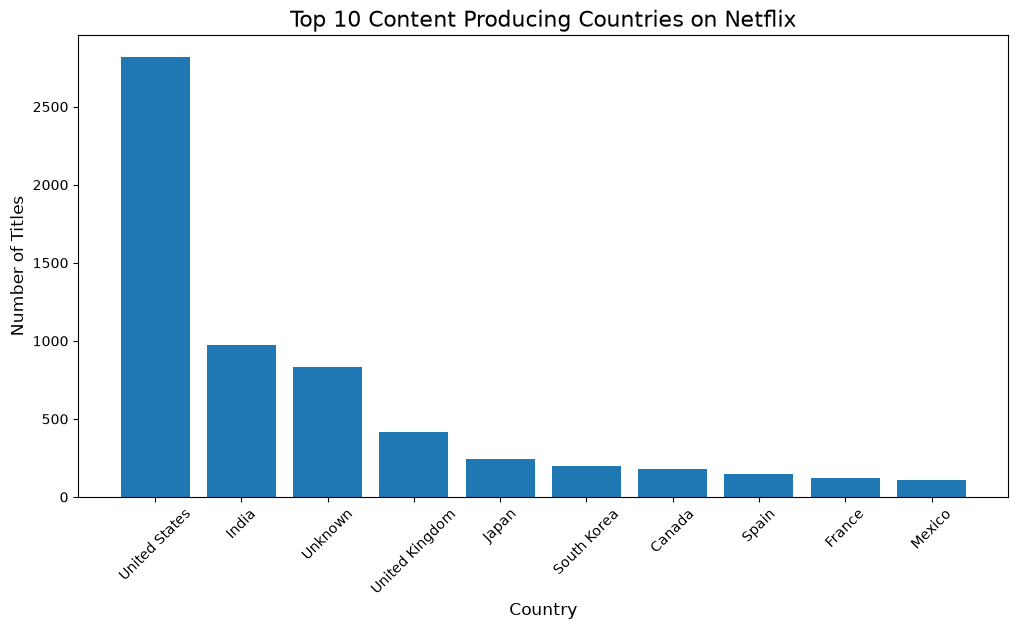

In [84]:
plt.figure(figsize=(12,6))

plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Content Producing Countries on Netflix", fontsize=16)

plt.xlabel("Country", fontsize=12)

plt.ylabel("Number of Titles", fontsize=12)

plt.xticks(rotation=45)

plt.show()

In [85]:
df_clean["country"].value_counts().head(15)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Turkey             105
Nigeria             95
Australia           87
Taiwan              81
Name: count, dtype: int64

In [86]:
df_clean["country"].unique()


<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                               'Unknown',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
                             'United States, East Germany, West Germany',
                   

In [87]:
repr(df_clean["country"].value_counts().index[2])

"'Unknown'"

In [88]:
df_clean["country"] = df_clean["country"].str.strip()

In [89]:
country_counts = (
    df_clean[df_clean["country"] != "Unknown"]["country"]
    .value_counts()
    .head(10)
)

country_counts

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [90]:
df_clean.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'day_added'],
      dtype='str')

In [91]:
df_clean["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [92]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")

In [93]:
df_clean["date_added"].dtype

dtype('<M8[us]')

In [94]:
df_clean["year_added"] = df_clean["date_added"].dt.year
df_clean["month_added"] = df_clean["date_added"].dt.month_name()
df_clean["day_added"] = df_clean["date_added"].dt.day

In [95]:
df_clean.columns



Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'day_added'],
      dtype='str')

In [96]:
yearly_additions = df_clean["year_added"].value_counts().sort_index()

yearly_additions

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

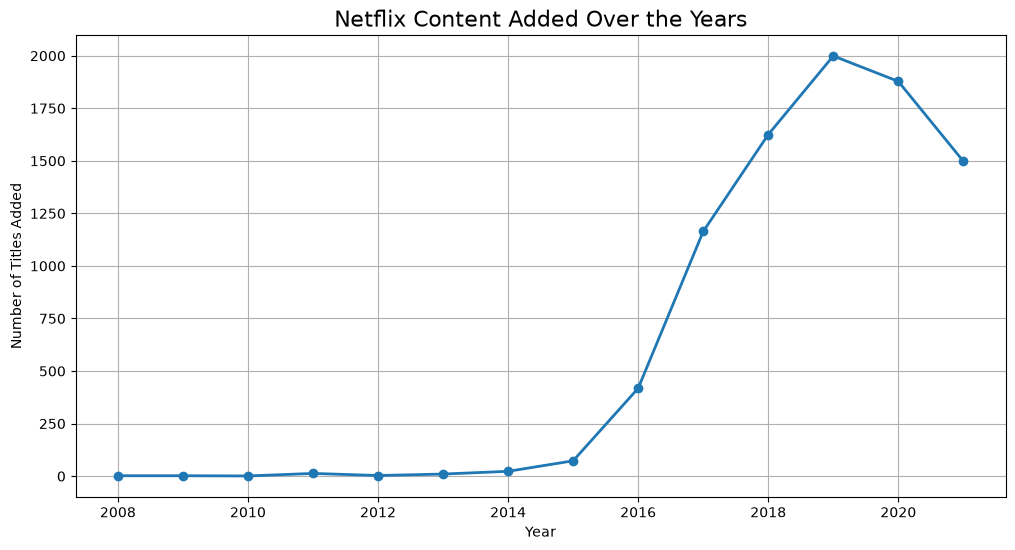

In [97]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_additions.index,
    yearly_additions.values,
    marker="o",
    linewidth=2
)

plt.title("Netflix Content Added Over the Years", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Number of Titles Added")

plt.grid(True)

plt.show()

In [98]:
release_trend = df_clean["release_year"].value_counts().sort_index()

release_trend


release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

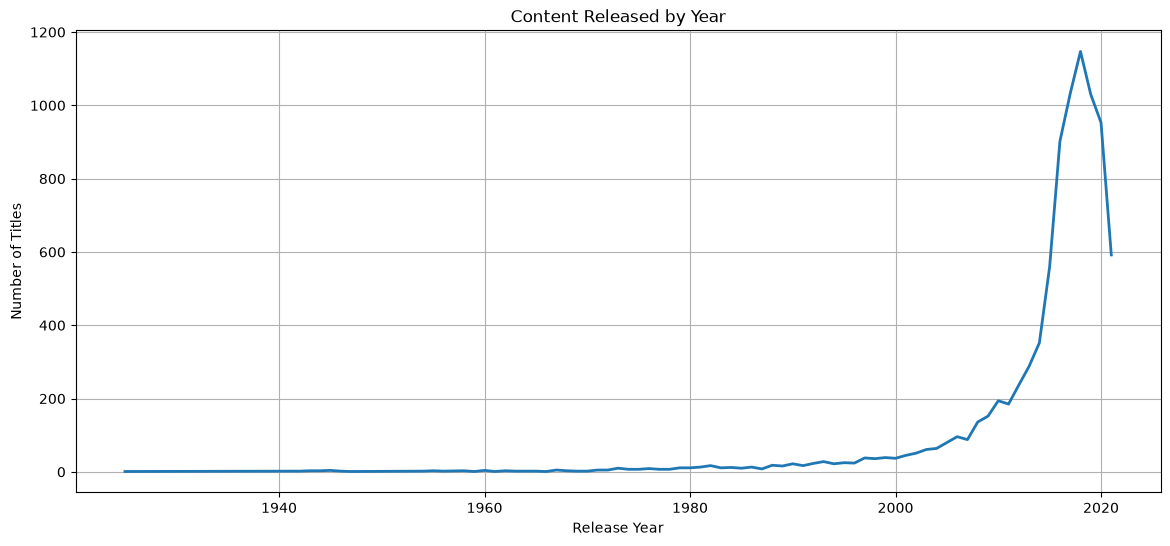

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    release_trend.index,
    release_trend.values,
    linewidth=2
)

plt.title("Content Released by Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

In [100]:
df_clean["content_age_when_added"] = (
    df_clean["year_added"] - df_clean["release_year"]
)

In [101]:
df_clean[
    ["title", "release_year", "year_added", "content_age_when_added"]
].head(10)

,title,release_year,year_added,content_age_when_added
0,Dick Johnson Is Dead,2020,2021.0,1.0
1,Blood & Water,2021,2021.0,0.0
2,Ganglands,2021,2021.0,0.0
3,Jailbirds New Orleans,2021,2021.0,0.0
4,Kota Factory,2021,2021.0,0.0
5,Midnight Mass,2021,2021.0,0.0
6,My Little Pony: A New Generation,2021,2021.0,0.0
7,Sankofa,1993,2021.0,28.0
8,The Great British Baking Show,2021,2021.0,0.0
9,The Starling,2021,2021.0,0.0


In [102]:
df_clean["content_age_when_added"].describe()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age_when_added, dtype: float64

In [103]:
df_clean[df_clean["content_age_when_added"] < 0][
    ["title", "release_year", "year_added", "date_added"]
]

,title,release_year,year_added,date_added
1551,Hilda,2021,2020.0,2020-12-14
1696,Polly Pocket,2021,2020.0,2020-11-15
2920,Love Is Blind,2021,2020.0,2020-02-13
3168,Fuller House,2020,2019.0,2019-12-06
3287,Maradona in Mexico,2020,2019.0,2019-11-13
3369,BoJack Horseman,2020,2019.0,2019-10-25
3433,The Hook Up Plan,2020,2019.0,2019-10-11
4844,Unbreakable Kimmy Schmidt,2019,2018.0,2018-05-30
4845,Arrested Development,2019,2018.0,2018-05-29
5394,Hans Teeuwen: Real Rancour,2018,2017.0,2017-07-01


In [104]:
negative_count = (df_clean["content_age_when_added"] < 0).sum()

negative_percentage = (negative_count / len(df_clean)) * 100

print("Negative Records:", negative_count)
print("Percentage:", round(negative_percentage, 3), "%")



Negative Records: 14
Percentage: 0.159 %


In [105]:
movies = df_clean[df_clean["type"] == "Movie"].copy()

In [106]:
movies["duration_minutes"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)



In [107]:
movies[["title", "duration", "duration_minutes"]].head()


,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90
6,My Little Pony: A New Generation,91 min,91
7,Sankofa,125 min,125
9,The Starling,104 min,104
12,Je Suis Karl,127 min,127


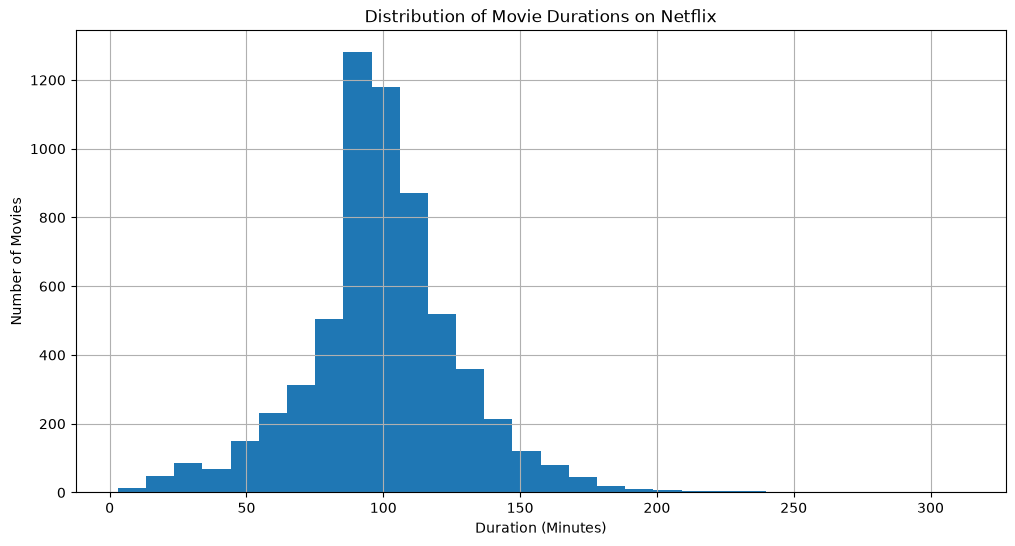

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(
    movies["duration_minutes"],
    bins=30
)

plt.title("Distribution of Movie Durations on Netflix")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Number of Movies")

plt.grid(True)

plt.show()


In [109]:
movies["duration_minutes"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [110]:
rating_counts = df_clean["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

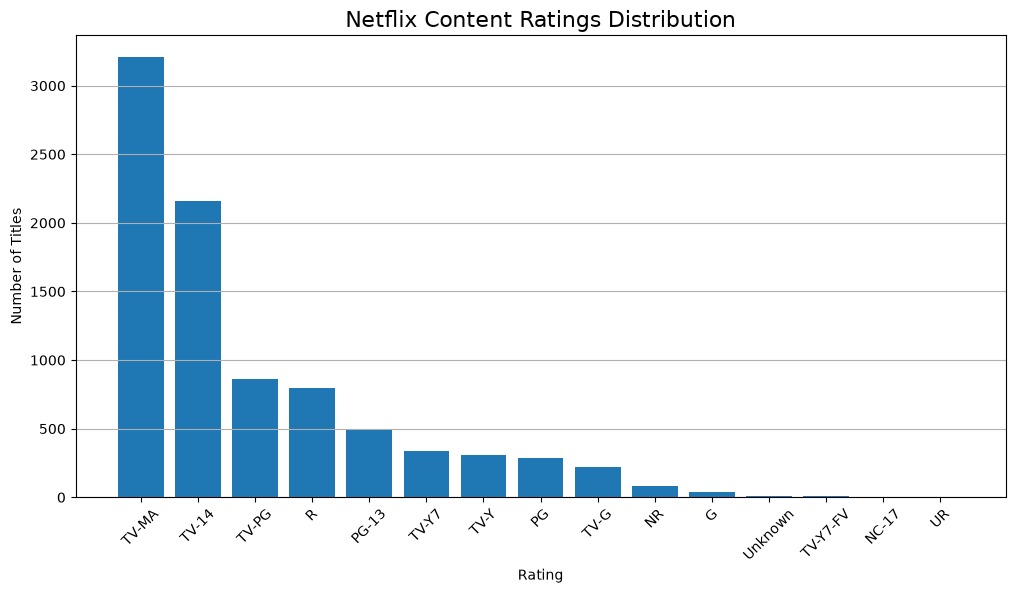

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title("Netflix Content Ratings Distribution", fontsize=16)

plt.xlabel("Rating")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

## Business Question 7: Audience Rating Analysis

### Objective
Analyze Netflix's content ratings to identify its primary target audience.

### Observation
- TV-MA is the most common content rating.
- Adult-oriented content dominates the Netflix catalog.
- Content for children and families represents a smaller portion of the library.

### Business Insight
The analysis indicates that Netflix primarily targets adult audiences. This reflects viewing habits where adults are the primary subscribers and tend to consume more mature genres such as crime, drama, thrillers, documentaries, and action.

### Recommendation
Netflix should continue investing in adult-oriented content while gradually expanding family-friendly and children's programming. This balanced strategy can help retain its core audience while attracting new subscribers from different age groups.

In [112]:
content_percentage = pd.crosstab(
    df_clean["year_added"],
    df_clean["type"],
    normalize="index"
) * 100

content_percentage.round(2)

type,Movie,TV Show
year_added,,
2008.0,50.00,50.00
2009.0,100.00,0.00
2010.0,100.00,0.00
2011.0,100.00,0.00
2012.0,100.00,0.00
2013.0,60.00,40.00
2014.0,82.61,17.39
2015.0,76.71,23.29
2016.0,60.53,39.47


In [113]:
content_by_year = pd.crosstab(
    df_clean["year_added"],
    df_clean["type"]
)

content_by_year

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165


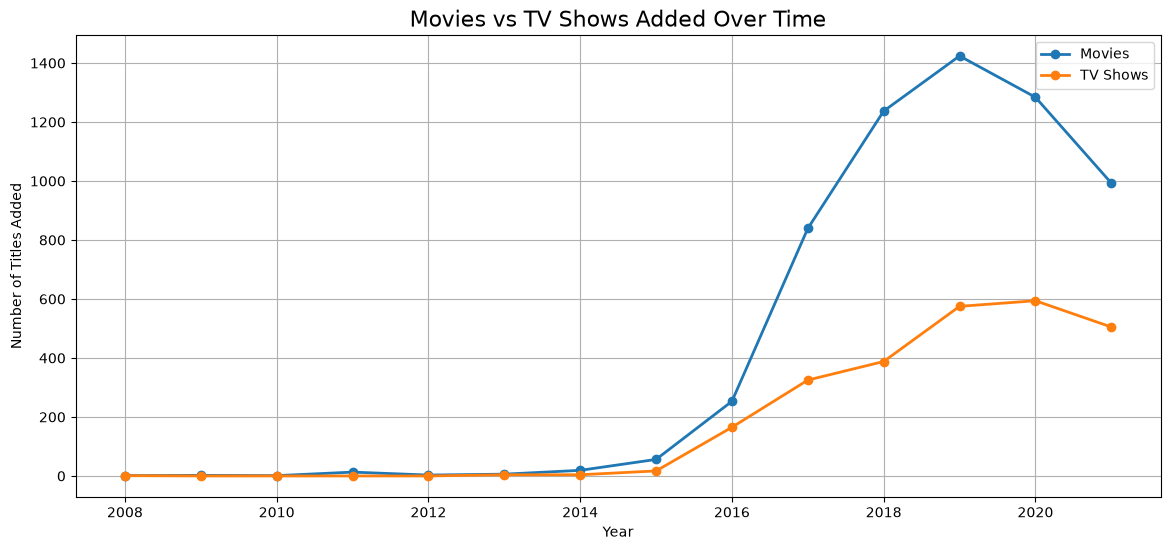

In [114]:
plt.figure(figsize=(14,6))

plt.plot(
    content_by_year.index,
    content_by_year["Movie"],
    marker="o",
    linewidth=2,
    label="Movies"
)

plt.plot(
    content_by_year.index,
    content_by_year["TV Show"],
    marker="o",
    linewidth=2,
    label="TV Shows"
)

plt.title("Movies vs TV Shows Added Over Time", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Number of Titles Added")

plt.legend()

plt.grid(True)

plt.show()

In [115]:
content_percentage = (
    pd.crosstab(
        df_clean["year_added"],
        df_clean["type"],
        normalize="index"
    ) * 100
).round(2)

content_percentage

type,Movie,TV Show
year_added,,
2008.0,50.00,50.00
2009.0,100.00,0.00
2010.0,100.00,0.00
2011.0,100.00,0.00
2012.0,100.00,0.00
2013.0,60.00,40.00
2014.0,82.61,17.39
2015.0,76.71,23.29
2016.0,60.53,39.47


## Business Question 8: Has Netflix Shifted from Movies to TV Shows?

### Objective
Analyze how Netflix's content strategy has evolved over time.

### Observation
- Movies consistently make up the majority of new content additions.
- TV Shows have gradually increased as a percentage of annual additions.
- Movie additions peaked around 2019, while TV Show additions continued growing into 2020.

### Business Insight
Netflix continues to prioritize Movies, but the growing share of TV Shows suggests an increasing investment in serialized content to improve viewer engagement and subscriber retention.

### Recommendation
Maintain a balanced content strategy by continuing to produce popular Movies while expanding high-quality TV Shows to strengthen long-term user engagement.

In [116]:
monthly_additions = df_clean["month_added"].value_counts()

monthly_additions

month_added
July         819
December     797
September    765
April        759
October      755
August       749
March        734
January      727
June         724
November     697
May          626
February     557
Name: count, dtype: int64

In [117]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_additions = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

monthly_additions

month_added
January      727
February     557
March        734
April        759
May          626
June         724
July         819
August       749
September    765
October      755
November     697
December     797
Name: count, dtype: int64

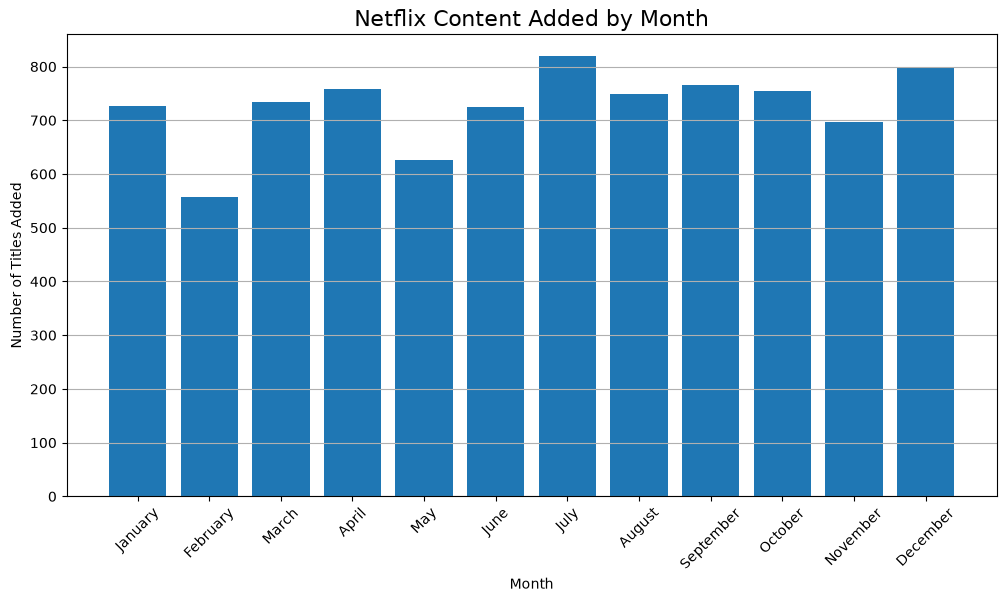

In [118]:
plt.figure(figsize=(12,6))

plt.bar(
    monthly_additions.index,
    monthly_additions.values
)

plt.title("Netflix Content Added by Month", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Number of Titles Added")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [119]:
monthly_type = pd.crosstab(
    df_clean["month_added"],
    df_clean["type"]
)

monthly_type = monthly_type.reindex(month_order)

monthly_type

type,Movie,TV Show
month_added,,
January,546,181
February,382,175
March,529,205
April,550,209
May,439,187
June,492,232
July,565,254
August,519,230
September,519,246


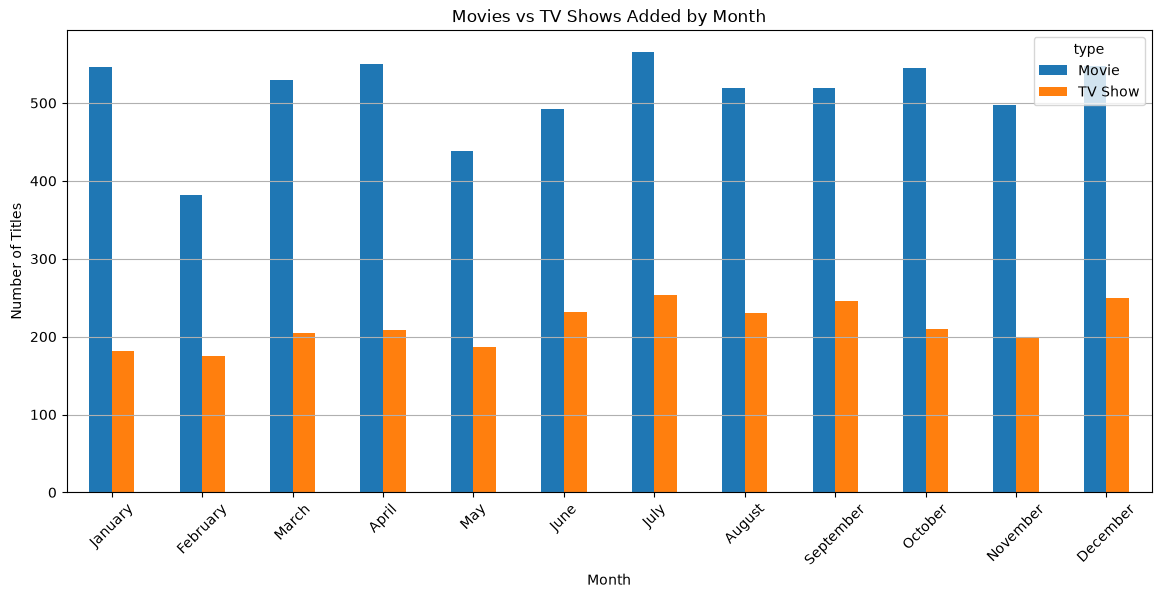

In [120]:
monthly_type.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Movies vs TV Shows Added by Month")

plt.xlabel("Month")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

## Business Question 9: Monthly Content Additions

### Objective

Analyze whether Netflix follows seasonal content release patterns.

### Observation

- July has the highest number of content additions.
- December also experiences a significant increase.
- February records the fewest content additions.

### Business Insight

Netflix appears to strategically schedule content releases during periods when user engagement is expected to be higher, such as summer vacations and year-end holidays.

### Recommendation

Netflix should continue leveraging seasonal viewing behavior by releasing flagship content during high-engagement months while exploring opportunities to increase high-quality releases during quieter months like February to maintain consistent subscriber engagement throughout the year.

In [121]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [122]:
top_countries = (
    df_clean[df_clean["country"] != "Unknown"]["country"]
    .value_counts()
    .head(10)
)

fig = px.bar(
    x=top_countries.index,
    y=top_countries.values,
    title="Top 10 Content Producing Countries",
    labels={
        "x":"Country",
        "y":"Number of Titles"
    },
    color=top_countries.values,
    color_continuous_scale="Reds"
)

fig.show()


In [123]:
type(genres)




pandas.Series

In [124]:
print(type(genres))

<class 'pandas.Series'>


In [125]:
print(genres.head())



0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in, dtype: object


In [126]:
print(genres.name)






listed_in


In [127]:
total_genres = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
    .nunique()
)

print(total_genres)

42


In [128]:
genres = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
)

print(genres.head(10))

0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
2    International TV Shows
2     TV Action & Adventure
3                Docuseries
3                Reality TV
4    International TV Shows
Name: listed_in, dtype: str


In [129]:
total_genres = genres.nunique()

print(total_genres)

42


In [130]:
print(df_clean["listed_in"].head())

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str


In [131]:
genres = df_clean["listed_in"].str.split(", ").explode()

print(genres.head(10))
print(type(genres))


0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
2    International TV Shows
2     TV Action & Adventure
3                Docuseries
3                Reality TV
4    International TV Shows
Name: listed_in, dtype: str
<class 'pandas.Series'>


In [132]:
total_genres = genres.nunique()

print(total_genres)

42


In [133]:
total_titles = len(df_clean)

total_movies = (df_clean["type"] == "Movie").sum()

total_tv = (df_clean["type"] == "TV Show").sum()

total_countries = df_clean["country"].nunique()

total_genres = genres.nunique()

print(f"📺 Total Titles: {total_titles}")
print(f"🎬 Movies: {total_movies}")
print(f"📺 TV Shows: {total_tv}")
print(f"🌍 Countries: {total_countries}")
print(f"🎭 Genres: {total_genres}")

📺 Total Titles: 8807
🎬 Movies: 6131
📺 TV Shows: 2676
🌍 Countries: 749
🎭 Genres: 42


In [134]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [135]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_titles,
        title={"text": "<b>Total Titles</b>"},
        number={"font": {"size": 48}}
    )
)

fig.update_layout(
    title="Netflix Dashboard",
    height=300
)

fig.show()

In [136]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type":"indicator"},{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}]]
)

# Total Titles
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_titles,
        title={"text":"📺<br>Total Titles"},
        number={"valueformat":",d"}
    ),
    row=1,col=1
)

# Movies
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_movies,
        title={"text":"🎬<br>Movies"},
        number={"valueformat":",d"}
    ),
    row=1,col=2
)

# TV Shows
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_tv,
        title={"text":"📺<br>TV Shows"},
        number={"valueformat":",d"}
    ),
    row=1,col=3
)

# Genres
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_genres,
        title={"text":"🎭<br>Genres"},
        number={"valueformat":",d"}
    ),
    row=1,col=4
)

fig.update_layout(
    height=250,
    title={
        "text":"🎬 Netflix Content Dashboard",
        "x":0.5,
        "font":{"size":28}
    },
    margin=dict(t=80,b=20,l=20,r=20)
)

fig.show()

In [137]:
fig.update_layout(
    title={
        "text":"<b>🎬 NETFLIX CONTENT DASHBOARD</b>",
        "x":0.5,
        "font":{
            "size":30,
            "color":"#E50914"     # Netflix Red
        }
    },

    paper_bgcolor="#141414",      # Entire dashboard background
    plot_bgcolor="#141414",

    font={
        "family":"Arial",
        "color":"white"
    },

    height=260,

    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    )
)

In [138]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ----------------------------
# KPI VALUES
# ----------------------------
total_titles = len(df_clean)
total_movies = (df_clean["type"] == "Movie").sum()
total_tv = (df_clean["type"] == "TV Show").sum()
total_countries = df_clean["country"].nunique()

# ----------------------------
# CREATE DASHBOARD
# ----------------------------
fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type":"indicator"},
            {"type":"indicator"},
            {"type":"indicator"},
            {"type":"indicator"}]]
)

# ----------------------------
# TOTAL TITLES
# ----------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_titles,
        title={
            "text":"<b>Total Titles</b>",
            "font":{"size":22}
        },
        number={
            "valueformat":",d",
            "font":{
                "size":52,
                "color":"#E50914"
            }
        }
    ),
    row=1,
    col=1
)

# ----------------------------
# MOVIES
# ----------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_movies,
        title={
            "text":"<b>Movies</b>",
            "font":{"size":22}
        },
        number={
            "valueformat":",d",
            "font":{
                "size":52,
                "color":"#E50914"
            }
        }
    ),
    row=1,
    col=2
)

# ----------------------------
# TV SHOWS
# ----------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_tv,
        title={
            "text":"<b>TV Shows</b>",
            "font":{"size":22}
        },
        number={
            "valueformat":",d",
            "font":{
                "size":52,
                "color":"#E50914"
            }
        }
    ),
    row=1,
    col=3
)

# ----------------------------
# COUNTRIES
# ----------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_countries,
        title={
            "text":"<b>Countries</b>",
            "font":{"size":22}
        },
        number={
            "valueformat":",d",
            "font":{
                "size":52,
                "color":"#E50914"
            }
        }
    ),
    row=1,
    col=4
)

# ----------------------------
# LAYOUT
# ----------------------------
fig.update_layout(

    title={
        "text":"<b>🎬 NETFLIX CONTENT DASHBOARD</b>",
        "x":0.5,
        "font":{
            "size":30,
            "color":"#E50914"
        }
    },

    paper_bgcolor="#141414",
    plot_bgcolor="#141414",

    font=dict(
        family="Arial",
        color="white"
    ),

    height=280,

    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    )
)

fig.show()

In [168]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(

    rows=5,
    cols=4,

    specs=[

        # KPI Row
        [{"type":"indicator"},
         {"type":"indicator"},
         {"type":"indicator"},
         {"type":"indicator"}],

        # Hero Chart (spans all 4 columns)
        [{"type":"xy","colspan":4},
         None,
         None,
         None],

        # Row 3
        [{"type":"xy","colspan":2},
         None,
         {"type":"xy","colspan":2},
         None],

        # Row 4
        [{"type":"xy","colspan":2},
         None,
         {"type":"xy","colspan":2},
         None],

        # Row 5
        [{"type":"xy","colspan":2},
         None,
         {"type":"xy","colspan":2},
         None]

    ],

    subplot_titles=(

        "", "", "", "",

        "📈 Netflix Content Growth",

        "🌍 Top Countries",
        "🎭 Top Genres",

        "⭐ Ratings Distribution",
        "⏱ Movie Duration",

        "📅 Monthly Additions",
        "🎬 Movies vs TV Shows"

    ),

    vertical_spacing=0.08,
    horizontal_spacing=0.08
)

In [169]:
yearly_additions

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [176]:
fig.add_trace(

   go.Scatter(

    x=yearly_additions.index,
    y=yearly_additions.values,

    mode="lines+markers",

    line=dict(
        color="#E50914",
        width=5
    ),

    marker=dict(
        size=9,
        color="white",
        line=dict(
            color="#E50914",
            width=2
        )
    ),

    hovertemplate="<b>Year:</b> %{x}<br><b>Titles Added:</b> %{y}<extra></extra>"
   )
)

In [178]:
peak_year = yearly_additions.idxmax()
peak_value = yearly_additions.max()

fig.add_annotation(
    x=peak_year,
    y=peak_value,
    text=f"🚀 Peak: {peak_year}",
    showarrow=True,
    arrowhead=2,
    arrowcolor="white",
    font=dict(color="white")
)

In [179]:
top_countries = (
    df_clean[df_clean["country"]!="Unknown"]["country"]
    .value_counts()
    .head(10)
)

In [180]:
fig.add_trace(

    go.Bar(

        x=top_countries.values,
        y=top_countries.index,

        orientation="h",

        marker_color="#E50914",

        name="Countries"

    ),

    row=2,
    col=2
)

ValueError: 
No subplot specified at grid position (2, 2)

In [ ]:
top_genres = genres.value_counts().head(10)

In [ ]:
fig.add_trace(

    go.Bar(

        x=top_genres.values,
        y=top_genres.index,

        orientation="h",

        marker_color="#B20710"

    ),

    row=3,
    col=1
)

In [ ]:
rating_counts = (
    df_clean["rating"]
    .value_counts()
)

In [ ]:
fig.add_trace(

    go.Bar(

        x=rating_counts.index,
        y=rating_counts.values,

        marker_color="#E50914"

    ),

    row=3,
    col=2
)

In [ ]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

In [ ]:
fig.add_trace(

    go.Bar(

        x=monthly.index,
        y=monthly.values,

        marker_color="#E50914"

    ),

    row=4,
    col=1
)

In [ ]:
fig.add_trace(

    go.Histogram(

        x=movies["duration_minutes"],

        nbinsx=30,

        marker_color="#E50914"

    ),

    row=4,
    col=2
)

In [ ]:

fig.update_layout(

    template="plotly_dark",

    paper_bgcolor="#0F0F0F",
    plot_bgcolor="#1A1A1A",

    title=dict(
        text="<b>NETFLIX CONTENT ANALYTICS DASHBOARD</b><br><sup>Business Intelligence Dashboard</sup>",
        x=0.5,
        font=dict(
            size=30,
            color="#E50914"
        )
    ),

    font=dict(
        family="Segoe UI",
        color="white",
        size=13
    ),

    showlegend=False,

    height=1800,

    margin=dict(
        l=50,
        r=50,
        t=100,
        b=60
    )
)

fig.show()

In [ ]:
# Split multiple countries into separate rows

countries = (
    df_clean["country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# Remove Unknown values
countries = countries[countries != "Unknown"]

# Top countries
country_counts = countries.value_counts()

country_counts.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [ ]:
total_countries = countries.nunique()

print(total_countries)

123


In [ ]:
top10_countries = country_counts.head(10)

fig.add_trace(

    go.Bar(

        x=top10_countries.values,
        y=top10_countries.index,

        orientation="h",

        marker=dict(
            color="#E50914"
        ),

        hovertemplate="<b>%{y}</b><br>Titles: %{x}<extra></extra>"

    ),

    row=2,
    col=2
)

In [ ]:
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

In [ ]:
fig.update_xaxes(
    showgrid=True,
    gridcolor="#333333"
)

In [ ]:
hovertemplate="<b>Year:</b> %{x}<br><b>Titles:</b> %{y}<extra></extra>"
hovertemplate="<b>%{x}</b><br>Titles: %{y}<extra></extra>"
hovertemplate="Runtime: %{x} min<br>Movies: %{y}<extra></extra>"

In [ ]:
title=dict(
    text="""
<b>NETFLIX CONTENT ANALYTICS DASHBOARD</b><br>
<sup>Interactive Business Intelligence Dashboard | Dataset: Netflix Titles</sup>
""",
    x=0.5,
    font=dict(
        size=28,
        color="#E50914"
    )
)

In [ ]:
fig.add_annotation(
    text="Created by Arpita Nair | Python • Pandas • Plotly",
    x=0.5,
    y=-0.08,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(size=12, color="gray")
)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

NETFLIX_RED = "#E50914"
BACKGROUND = "#111111"
CARD = "#1A1A1A"
GRID = "#333333"
TEXT = "white"
ACCENT = "#46C2CB"
GOLD = "#F5C518"

In [ ]:
fig.add_annotation(
    x=2019,
    y=1999,
    text="Peak: 2019",
    showarrow=True,
    arrowhead=2,
    font=dict(color="white")
)

In [181]:
import streamlit as st

st.set_page_config(
    page_title="Netflix Content Analytics",
    page_icon="🎬",
    layout="wide"
)

st.title("🎬 Netflix Content Analytics Dashboard")

st.write("Welcome to my first Business Intelligence Dashboard!")





2026-07-10 18:24:06.882 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:24:06.884 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:24:07.291 
  command:

    streamlit run c:\Users\naira\OneDrive\Desktop\Netflix_Data_Analysis\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-10 18:24:07.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:24:07.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:24:07.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:24:07.296 Thread 'MainThread': missing ScriptRunContext! Th

In [184]:
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Netflix Content Analytics",
    page_icon="🎬",
    layout="wide"
)

st.title("🎬 Netflix Content Analytics Dashboard")

df = pd.read_csv("data/raw/netflix_titles.csv")

total_titles = len(df)
movies = (df["type"] == "Movie").sum()
tv = (df["type"] == "TV Show").sum()

countries = (
    df["country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .nunique()
)

col1, col2, col3, col4 = st.columns(4)

col1.metric("📺 Total Titles", f"{total_titles:,}")
col2.metric("🎬 Movies", f"{movies:,}")
col3.metric("📺 TV Shows", f"{tv:,}")
col4.metric("🌍 Countries", countries)

2026-07-10 18:53:06.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:53:06.482 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:53:06.483 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 18:53:06.484 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/netflix_titles.csv'

In [185]:
import os

print(os.getcwd())

c:\Users\naira\OneDrive\Desktop\Netflix_Data_Analysis\notebooks


In [187]:
df = pd.read_csv("../data/raw/netflix_titles.csv")
